# Hyperparameter sweep analysis

Pulls all runs from the hyperparameter-sweep W&B projects, ranks hyperparameter
combinations (`COMBO_ID`) by mean best test return across their 3 seeds, and —
per algorithm — tabulates the top N combos with their hyperparameters and plots
their learning curves.

Uses `evaluation/utils/wandb_utils.py` (`download_run`, `store_run_data`) and
`evaluation/utils/run_data_handling.py` (`Run`) — same pattern as `evaluate_runs.py`.
Downloaded runs are cached under `evaluation/data/hyper_parameter_tuning/`, so
re-running this notebook only fetches new runs.

In [1]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

from utils.wandb_utils import download_run, store_run_data
from utils.run_data_handling import Run

api = wandb.Api()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /Users/pbhustali/.netrc.


In [2]:
ENTITY = "imp-act"
PROJECTS = ["hyper_parameter_tuning_Cologne-v1", "hyper_parameter_tuning"]
METRIC = "test_returned_episode_returns"
CACHE_DIR = Path("data/hyper_parameter_tuning")
TOP_N = 5
MAX_WORKERS = 8

## Pull + cache runs

Downloads any run not already cached (in parallel, with a progress bar), then
loads every run (cached or fresh) through `Run` and builds one row per run
(`runs_df`) with its best/final test return. Loaded `Run` objects are kept in
`loaded_runs`, keyed by `(project, run_id)`.

In [3]:
from tqdm.auto import tqdm


def _load_one_run(project, remote_run, cache_dir):
    run_path = cache_dir / project / remote_run.id
    if not (run_path / "config.yaml").exists():
        run_data = download_run(remote_run)
        store_run_data(run_data, run_path)

    run = Run(run_path)
    metric_values = run.get_history_values(METRIC)
    if metric_values is None or metric_values.dropna().empty:
        return None

    metric_values = metric_values.dropna()
    row = {
        "project": project,
        "run_id": run.id,
        "alg": run.config.get("ALG_NAME"),
        "combo_id": run.config.get("COMBO_ID"),
        "run_label": run.config.get("RUN_LABEL"),
        "seed": run.config.get("SEED"),
        "best_test_return": metric_values.max(),
        "final_test_return": metric_values.iloc[-1],
    }
    return run, row


def load_all_runs(entity, projects, cache_dir, max_workers=MAX_WORKERS):
    finished_runs = [
        (project, remote_run)
        for project in projects
        for remote_run in api.runs(f"{entity}/{project}")
        if remote_run.state == "finished"
    ]

    rows = []
    loaded_runs = {}
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [
            executor.submit(_load_one_run, project, remote_run, cache_dir)
            for project, remote_run in finished_runs
        ]
        for future in tqdm(
            as_completed(futures), total=len(futures), desc="Loading runs"
        ):
            result = future.result()
            if result is None:
                continue
            run, row = result
            loaded_runs[(row["project"], run.id)] = run
            rows.append(row)

    return pd.DataFrame(rows), loaded_runs


runs_df, loaded_runs = load_all_runs(ENTITY, PROJECTS, CACHE_DIR)
print(f"Loaded {len(runs_df)} finished runs")
runs_df.head()

/Users/pbhustali/Documents/GitHub/imp-act-JaxMARL/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading runs: 100%|██████████| 132/132 [00:00<00:00, 192.84it/s]

Loaded 132 finished runs


,project,run_id,alg,combo_id,run_label,seed,best_test_return,final_test_return
0,hyper_parameter_tuning_Cologne-v1,d0hjp90w,pqn_rnn,C0002,C0002_2,102,-2.616608e+10,-3.075077e+10
1,hyper_parameter_tuning_Cologne-v1,fw9avkbn,pqn_rnn,C0002,C0002_1,101,-1.321897e+10,-1.431561e+10
2,hyper_parameter_tuning_Cologne-v1,9m7eru1a,pqn_rnn,C0003,C0003_2,102,-1.487042e+10,-1.980225e+10
3,hyper_parameter_tuning_Cologne-v1,01unq1yi,pqn_rnn,C0002,C0002_3,103,-2.351469e+10,-3.353045e+10
4,hyper_parameter_tuning_Cologne-v1,t311lggg,pqn_rnn,C0001,C0001_2,102,-2.044918e+10,-2.763437e+10


## Rank combos

Average `best_test_return` (max over each run's test-return history) across
the 3 seeds of every `COMBO_ID`, then take the top N combos per algorithm.
`top_combos_by_alg` maps each algorithm to its own DataFrame of top combos,
sorted best-first, and one table per algorithm is shown below.
`n_seeds` below `3` means not all seeds for that combo have finished yet —
treat those rankings as provisional.

In [4]:
combo_df = (
    runs_df.groupby(["project", "alg", "combo_id"])
    .agg(
        mean_best_test_return=("best_test_return", "mean"),
        std_best_test_return=("best_test_return", "std"),
        n_seeds=("run_id", "count"),
    )
    .reset_index()
    .sort_values("mean_best_test_return", ascending=False)
)
combo_df["rank_within_alg"] = combo_df.groupby(["project", "alg"]).cumcount() + 1

top_combos = (
    combo_df[combo_df["rank_within_alg"] <= TOP_N]
    .drop(columns="rank_within_alg")
    .reset_index(drop=True)
)

top_combos_by_alg = {
    alg: alg_df.reset_index(drop=True) for alg, alg_df in top_combos.groupby("alg")
}

for alg, alg_df in top_combos_by_alg.items():
    display(alg_df)

,project,alg,combo_id,mean_best_test_return,std_best_test_return,n_seeds
0,hyper_parameter_tuning,ippo_rnn,C0040,-1.256005e+10,5.406422e+08,3
1,hyper_parameter_tuning,ippo_rnn,C0048,-1.263881e+10,5.490651e+08,3
2,hyper_parameter_tuning,ippo_rnn,C0001,-1.286618e+10,5.428699e+08,3
3,hyper_parameter_tuning,ippo_rnn,C0030,-1.299082e+10,9.636802e+08,3
4,hyper_parameter_tuning,ippo_rnn,C0043,-1.302796e+10,1.032320e+09,3


,project,alg,combo_id,mean_best_test_return,std_best_test_return,n_seeds
0,hyper_parameter_tuning,mappo_rnn,C0001,-1.237532e+10,8.943744e+07,3


,project,alg,combo_id,mean_best_test_return,std_best_test_return,n_seeds
0,hyper_parameter_tuning_Cologne-v1,pqn_rnn,C0003,-1.272475e+10,1.933661e+09,3
1,hyper_parameter_tuning_Cologne-v1,pqn_rnn,C0016,-1.351177e+10,2.039636e+09,3
2,hyper_parameter_tuning_Cologne-v1,pqn_rnn,C0007,-1.377930e+10,6.181092e+08,3
3,hyper_parameter_tuning_Cologne-v1,pqn_rnn,C0014,-1.640233e+10,1.116467e+09,3
4,hyper_parameter_tuning_Cologne-v1,pqn_rnn,C0008,-1.739242e+10,1.744828e+09,3


## Hyperparameters of the top combos

One table per algorithm (`hyperparams_by_alg`), indexed by `rank` (1 = best)
and `combo_id`. Hyperparameters are read from the config of one sample run per
combo; bookkeeping keys listed in `NON_HYPERPARAM_KEYS` are filtered out.

In [5]:
NON_HYPERPARAM_KEYS = {
    "HYDRA_PATH",
    "SAVE_PATH",
    "WANDB_DIR",
    "COMBO_ID",
    "RUN_LABEL",
    "SEED",
    "ENTITY",
    "PROJECT",
    "WANDB_MODE",
    "HYP_TUNE",
    "ENV_NAME",
    "REWARD_STANDARDIZATION",
    "SCALE_CLIP_EPS",
    "DOUBLE_PRECISION_MODE",
    "ENV_KWARGS",
    "ALG_NAME",
}


def combo_hyperparams(project, alg, combo_id):
    sample_run_id = runs_df.query(
        "project == @project and alg == @alg and combo_id == @combo_id"
    ).iloc[0]["run_id"]
    run = loaded_runs[(project, sample_run_id)]
    return {k: v for k, v in run.config.items() if k not in NON_HYPERPARAM_KEYS}


hyperparams_by_alg = {}
for alg, alg_combos in top_combos_by_alg.items():
    rows = []
    for rank, (_, row) in enumerate(alg_combos.iterrows(), start=1):
        hp = combo_hyperparams(row["project"], alg, row["combo_id"])
        rows.append({"rank": rank, "combo_id": row["combo_id"], **hp})
    hyperparams_by_alg[alg] = pd.DataFrame(rows).set_index(["rank", "combo_id"])

for alg, alg_hp_df in hyperparams_by_alg.items():
    print(f"=== {alg} ===")
    display(alg_hp_df)

=== ippo_rnn ===


,,ACTIVATION,ANNEAL_LR,CLIP_EPS,ENT_COEF,FC_DIM_SIZE,GAE_LAMBDA,GAMMA,GRU_HIDDEN_DIM,LR,MAX_GRAD_NORM,...,SAVE_CHECKPOINTS,SAVE_CHECKPOINTS_INTERVAL,TEST_DURING_TRAINING,TEST_INTERVAL,TEST_NUM_ENVS,TEST_NUM_STEPS,TOTAL_TIMESTEPS,UPDATE_EPOCHS,VF_COEF,WANDB_LOG_ALL_SEEDS
rank,combo_id,,,,,,,,,,,,,,,,,,,,,
1,C0040,relu,False,0.1,0.001,128,0.98,0.99,128,0.00010,0.5,...,True,0.01,True,0.01,1000,50,50000000,8,0.5,False
2,C0048,relu,False,0.2,0.001,128,0.98,0.99,128,0.00010,0.5,...,True,0.01,True,0.01,1000,50,50000000,8,0.5,False
3,C0001,relu,False,0.2,0.001,128,0.98,0.99,128,0.00025,0.5,...,True,0.01,True,0.01,1000,50,50000000,4,0.5,False
4,C0030,relu,False,0.1,0.001,128,0.98,0.99,128,0.00050,0.5,...,True,0.01,True,0.01,1000,50,50000000,8,0.5,False
5,C0043,relu,False,0.2,0.001,128,0.98,0.99,128,0.00050,0.5,...,True,0.01,True,0.01,1000,50,50000000,8,0.5,False


=== mappo_rnn ===


,,ACTIVATION,ANNEAL_LR,CLIP_EPS,ENT_COEF,FC_DIM_SIZE,GAE_LAMBDA,GAMMA,GRU_HIDDEN_DIM,LR,MAX_GRAD_NORM,...,SAVE_CHECKPOINTS,SAVE_CHECKPOINTS_INTERVAL,TEST_DURING_TRAINING,TEST_INTERVAL,TEST_NUM_ENVS,TEST_NUM_STEPS,TOTAL_TIMESTEPS,UPDATE_EPOCHS,VF_COEF,WANDB_LOG_ALL_SEEDS
rank,combo_id,,,,,,,,,,,,,,,,,,,,,
1,C0001,relu,False,0.2,0.001,128,0.98,0.99,128,0.00025,0.5,...,True,0.01,True,0.01,1000,50,50000000,4,0.5,False


=== pqn_rnn ===


,,EPS_DECAY,EPS_FINISH,EPS_START,GAMMA,HIDDEN_SIZE,LAMBDA,LR,LR_LINEAR_DECAY,MAX_GRAD_NORM,MEMORY_WINDOW,...,NUM_STEPS,REW_SCALE,SAVE_CHECKPOINTS,SAVE_CHECKPOINTS_INTERVAL,TEST_DURING_TRAINING,TEST_INTERVAL,TEST_NUM_ENVS,TEST_NUM_STEPS,TOTAL_TIMESTEPS,WANDB_LOG_ALL_SEEDS
rank,combo_id,,,,,,,,,,,,,,,,,,,,,
1,C0003,0.1,0.00,1,0.99,128,0.85,0.0001,False,1.0,4,...,51,1.000000e-09,True,0.01,True,0.01,1000,50,50000000,False
2,C0016,0.1,0.00,1,0.99,128,0.65,0.0001,False,0.5,4,...,51,1.000000e-09,True,0.01,True,0.01,1000,50,50000000,False
3,C0007,0.1,0.01,1,0.99,128,0.95,0.0001,False,0.5,4,...,51,1.000000e-09,True,0.01,True,0.01,1000,50,50000000,False
4,C0014,0.1,0.01,1,0.99,512,0.95,0.0001,False,0.5,4,...,51,1.000000e-09,True,0.01,True,0.01,1000,50,50000000,False
5,C0008,0.1,0.01,1,0.99,128,0.85,0.0001,False,1.0,4,...,51,1.000000e-09,True,0.01,True,0.01,1000,50,50000000,False


## Learning curves for the top combos

One grid of `n_algs × TOP_N` panels: one row per algorithm, columns ordered by
rank (best combo leftmost), one line per seed. Axes are shared within each row,
so panels of the same algorithm are directly comparable; unused panels (fewer
than `TOP_N` combos for an algorithm) are hidden.

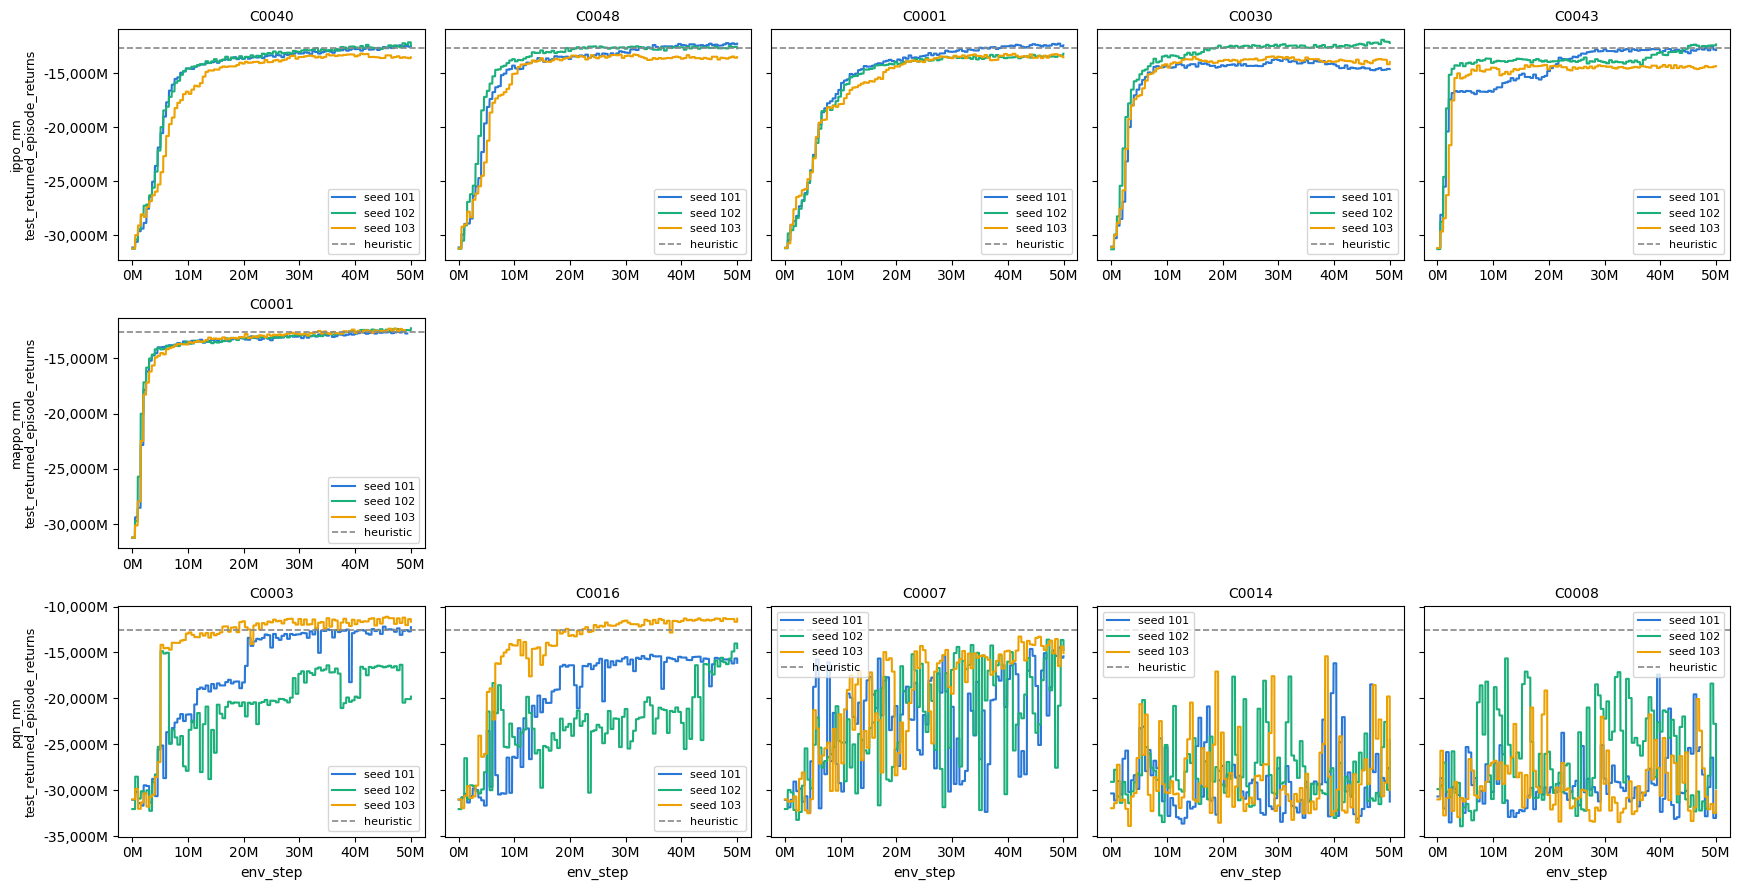

In [6]:
from matplotlib.ticker import FuncFormatter

# Fixed-order categorical palette (one hue per seed slot, never reassigned).
SEED_COLORS = ["#2a78d6", "#1baf7a", "#eda100"]
BASELINE_COLOR = "#888888"

HEURISTIC_BASELINE = -12.6e9  # heuristic baseline return (-12,600M)

millions_formatter = FuncFormatter(lambda v, _: f"{v / 1e6:,.0f}M")


def plot_combo_learning_curve(project, alg, combo_id, ax):
    combo_runs = runs_df.query(
        "project == @project and alg == @alg and combo_id == @combo_id"
    ).sort_values("run_label")

    for seed_idx, (_, r) in enumerate(combo_runs.iterrows()):
        run = loaded_runs[(project, r["run_id"])]
        x = run.get_history_values("env_step")
        y = run.get_history_values(METRIC)
        ax.plot(
            x, y,
            color=SEED_COLORS[seed_idx % len(SEED_COLORS)],
            linewidth=1.5,
            label=f"seed {r['seed']}",
        )

    ax.axhline(
        HEURISTIC_BASELINE,
        color=BASELINE_COLOR,
        linestyle="--",
        linewidth=1.2,
        label="heuristic",
    )
    ax.yaxis.set_major_formatter(millions_formatter)
    ax.xaxis.set_major_formatter(millions_formatter)
    ax.set_title(combo_id, fontsize=10)
    ax.legend(fontsize=8)


algs = list(top_combos_by_alg)
n_algs = len(algs)
fig, axes = plt.subplots(
    n_algs, TOP_N,
    figsize=(3.5 * TOP_N, 3.0 * n_algs),
    squeeze=False,
    sharex="row",
    sharey="row",
)

for row_idx, alg in enumerate(algs):
    alg_combos = top_combos_by_alg[alg]
    for col_idx in range(TOP_N):
        ax = axes[row_idx][col_idx]
        if col_idx >= len(alg_combos):
            ax.set_axis_off()
            continue
        combo = alg_combos.iloc[col_idx]
        plot_combo_learning_curve(combo["project"], alg, combo["combo_id"], ax)
        if col_idx == 0:
            ax.set_ylabel(f"{alg}\n{METRIC}", fontsize=9)

for ax in axes[-1]:
    ax.set_xlabel("env_step")

fig.tight_layout()
plt.show()